In [2]:
import pandas as pd 

df = pd.read_csv("../data/election.txt", sep="\t")

df.head()

,state,county,trump16_pct,clinton16_pct,otherpres16_pct,romney12_pct,obama12_pct,otherpres12_pct,senaterace16,houserace16,...,hispanic_pct,foreignborn_pct,female_pct,age29andunder_pct,age65andolder_pct,median_hh_inc,clf_unemploy_pct,lesshs_pct,lesscollege_pct,rural_pct
0,Alabama,Autauga,0.727666,0.237697,0.034637,0.726183,0.265878,0.007939,Race,Race,...,2.572254,1.838362,51.176225,40.037058,13.978456,53099,5.591657,12.417046,75.407229,42.002162
1,Alabama,Baldwin,0.765457,0.193856,0.040687,0.773583,0.215894,0.010523,Race,Race,...,4.366698,3.269510,51.194928,35.474412,18.714851,51365,6.286843,9.972418,70.452889,42.279099
2,Alabama,Barbour,0.520967,0.465278,0.013755,0.482231,0.513685,0.004084,Race,Race,...,4.309762,2.859397,46.498084,37.664387,16.528895,33956,12.824738,26.235928,87.132213,67.789635
3,Alabama,Bibb,0.764032,0.212496,0.023472,0.728266,0.261520,0.010214,Race,Race,...,2.223994,1.351232,46.464646,37.329435,14.885699,39776,7.146827,19.301587,88.000000,68.352607
4,Alabama,Blount,0.893348,0.084258,0.022393,0.864659,0.123719,0.011622,Race,Race,...,8.727298,4.271801,50.485235,37.240053,17.192916,46212,5.953833,19.968585,86.950243,89.951502


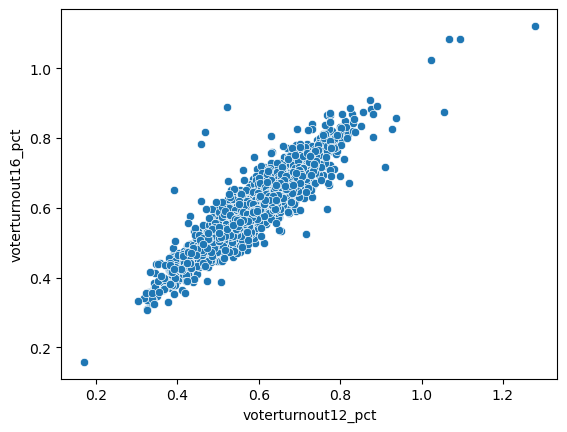

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(df, x="voterturnout12_pct", y="voterturnout16_pct")
plt.show()

In [4]:
# The excercise mentions "investigate counties where voter turnout > 100%"
# Im not sure why this would be

greater_than_100 = df[(df["voterturnout12_pct"] > 1) | (df["voterturnout16_pct"] > 1)]
greater_than_100.head()

# It asks me why, but im not sure, voter fraud?

,state,county,trump16_pct,clinton16_pct,otherpres16_pct,romney12_pct,obama12_pct,otherpres12_pct,senaterace16,houserace16,...,hispanic_pct,foreignborn_pct,female_pct,age29andunder_pct,age65andolder_pct,median_hh_inc,clf_unemploy_pct,lesshs_pct,lesscollege_pct,rural_pct
271,Colorado,San Juan,0.424901,0.523715,0.051383,0.418972,0.525692,0.055336,Race,Race,...,23.550725,0.543478,47.282609,27.355072,17.028986,41250,10.282776,4.595186,71.553611,100.0
1776,New Mexico,Harding,0.590133,0.296015,0.113852,0.544093,0.432612,0.023295,No Race,Race,...,41.946903,0.176991,48.672566,21.415929,28.849558,32404,5.963303,11.013216,74.229075,100.0
2361,South Dakota,Hanson,0.746261,0.211366,0.042373,0.673427,0.314570,0.012003,Race,Race,...,0.589971,0.058997,49.144543,43.333333,13.775811,60089,0.347423,7.826932,78.609626,100.0
2642,Texas,Loving,0.892308,0.061538,0.046154,0.843750,0.140625,0.015625,No Race,Race,...,15.789474,11.842105,47.368421,11.842105,25.000000,56875,0.000000,25.373134,97.014925,100.0
2647,Texas,McMullen,0.909820,0.080160,0.010020,0.856859,0.133201,0.009940,No Race,Race,...,48.137109,6.706408,45.603577,44.560358,28.017884,57589,15.151515,18.565401,83.755274,100.0


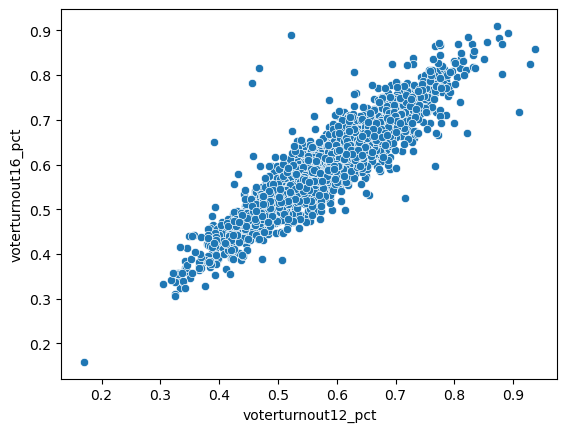

In [5]:
#
all_below_100 = df[(df["voterturnout12_pct"] < 1) & (df["voterturnout16_pct"] < 1)]
all_below_100.head()

sns.scatterplot(all_below_100, x="voterturnout12_pct", y="voterturnout16_pct")
plt.show()

In [6]:
# it looks like a linear, positive and strong correlation
# 0.924 so very strong
r = df["voterturnout12_pct"].corr(df["voterturnout16_pct"])
print(r)


0.9243095587512101


In [7]:
from scipy.stats import linregress
import numpy as np

turnout_12_pct = np.array(df["voterturnout12_pct"])
turnout_16_pct = np.array(df["voterturnout16_pct"])

slope, intercept, rvalue, pvalue, stderr = linregress(turnout_12_pct, turnout_16_pct)
print(slope, intercept, rvalue, pvalue, stderr)

0.8966540727295398 0.07592731571606937 0.92430955875121 0.0 0.0066398016694608625


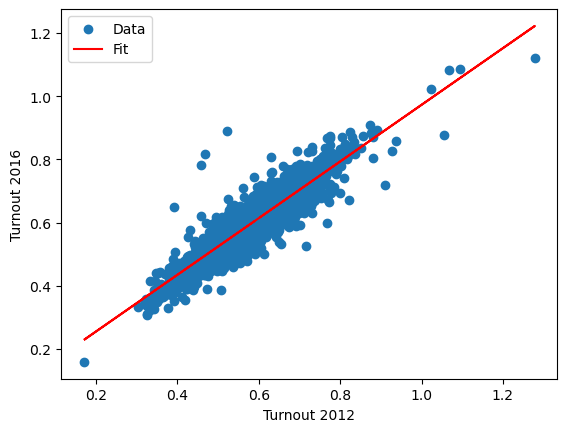

In [8]:
# lets graph it and see the scatter and regression
import matplotlib.pyplot as plt

# Plot
plt.scatter(turnout_12_pct, turnout_16_pct, label='Data')
plt.plot(turnout_12_pct, slope * turnout_12_pct + intercept, color='red', label='Fit')
plt.xlabel("Turnout 2012")
plt.ylabel("Turnout 2016")
plt.legend()
plt.show()

In [13]:
print(f"The slope is {slope:.4f} and the intercept is {intercept:.4f}, the intercept means that at theoretically 0 turnout we would expect to see {intercept:.2f} of the electorate voting. \nThe slope means that for every 1 increase in turnout we would expect to see an increase in turnout by a factor of {1 + slope:.2f}.")

The slope is 0.8967 and the intercept is 0.0759, the intercept means that at theoretically 0 turnout we would expect to see 0.08 of the electorate voting. 
The slope means that for every 1 increase in turnout we would expect to see an increase in turnout by a factor of 1.90.


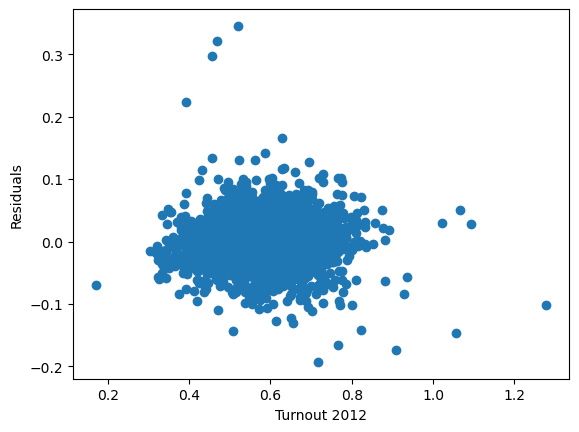

In [ ]:
# Residual plot
residuals = turnout_16_pct - (slope * turnout_12_pct + intercept)
plt.scatter(turnout_12_pct, residuals)
plt.xlabel("Turnout 2012")
plt.ylabel("Residuals")
plt.show()

In [ ]:
# Gila County in Arizona is northeast of Phoenix and includes parts of Fort Apache Indian Reservation and San Carlos Indian Reservation. 
# In 2012, the estimated voter turnout was about 52% of the civilian voting-age population; that figure increased to almost 89% in 2016. 
# Calculate the residual for Gila County using the linear regression model from Step 1 and use that value, along with the standard deviation of the residuals,
# in a sentence to provide some context about the utility of the model for prediction.

gila_pred = intercept + slope * 0.52
gila_residual = 0.89 - gila_pred

print(f"The residual for gila county was {gila_residual:.2f}. The standard deviation of error was {stderr:.2f}. This means the gila county would have a z-score of {gila_residual / stderr:.2f}. This shows that this model is not that effective for prediction.")



The residual for gila county was 0.35. The standard deviation of error was 0.01. This means the gila county would have a z-score of 52.38. This shows that this model is not that effective for prediction.


In [14]:
# calculate r^2
print(f"The r squared value is {r**2:.2f}")
print(f"The R squared value suggests that 85% of the variability in voter turnout in 2016 was accounted for by the variance in turnout in 2012")

The r squared value is 0.85
The R squared value suggests that 85% of the variability in voter turnout in 2016 was accounted for by the variance in turnout in 2012
